<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>

# Laboratorium nr 9: RNN - Szeregi czasowe. Attention.

## Import bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import datetime
import matplotlib.pyplot as plt

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Pandas version:", pd.__version__)

2026-04-08 09:43:59.962957: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 09:44:00.971522: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 09:44:03.142367: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Numpy version: 2.4.2
Tensorflow version: 2.20.0
Keras version: 3.13.2
Pandas version: 3.0.1


## Wczytanie danych
Dane o transakcjach umieszczone są w pliku `data_trade_PLKGHM000017.tar.gz'` (do poprania na platformie Delta). Dane są w formacie DataFrame z biblioteki pandas w pliku pickle dodatkowo skompresowane (`gzip`). W pliku znajdują się wszystkie transakcje spółki KGHM z lat 2014-2021.

In [ ]:
df = pd.read_pickle("data_trade_PLKGHM000017.tar.gz")
print("Liczba rekordów:", len(df))
df.head()

Liczba rekordów: 10262543


,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
0,1388649600006132000,1,118.8,1,200000000,,,O,B
1,1388649600006141000,2,118.8,10,200000000,,,O,B
2,1388649600006146000,3,118.8,10,200000000,,,O,B
3,1388649600006150000,4,118.8,10,200000000,,,O,B
4,1388649600006154000,5,118.8,10,200000000,,,O,B


In [ ]:
df["datetime"] = (pd.to_datetime(df["datetime"], unit="ns", utc=True)).dt.tz_convert(
    "Europe/Warsaw"
)
df.head()

,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
0,2014-01-02 09:00:00.006132+01:00,1,118.8,1,200000000,,,O,B
1,2014-01-02 09:00:00.006141+01:00,2,118.8,10,200000000,,,O,B
2,2014-01-02 09:00:00.006146+01:00,3,118.8,10,200000000,,,O,B
3,2014-01-02 09:00:00.006150+01:00,4,118.8,10,200000000,,,O,B
4,2014-01-02 09:00:00.006154+01:00,5,118.8,10,200000000,,,O,B


In [4]:
df.tail()

,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
10262538,2021-12-30 17:03:23.014534+01:00,3313,139.4,5,200000000,,,S,B
10262539,2021-12-30 17:03:23.014547+01:00,3314,139.4,7,200000000,,,S,B
10262540,2021-12-30 17:03:23.014550+01:00,3315,139.4,71,200000000,,,S,B
10262541,2021-12-30 17:03:23.014553+01:00,3316,139.4,14,200000000,,,S,B
10262542,2021-12-30 17:04:43.240023+01:00,3317,139.4,100,200000000,,,S,B


In [5]:
len(df)

10262543

### Opis kolumn

- `datetime` - cazas transakcji
- `trade_id` - unikalny numer transakcji
- `price` - cena transakcji
- `volume` - wolumen transakcji
- `nb_instruments` - ogólna ilość akcji (np. do policzenia kapitalizacji)
- `dividend` - gdy pojawi się `bd` to oznacza to, że jest to pierwszy dzień bez prawa do dywidendy
- `split` - gdy pojawi się `pw` to oznacza to, że jest to pierwszy dzień po splicie/resplicie
- `opening_trade_indicator` - zlecenie na otwarciu czy w trakcie sesji:
   - `O` - Opening
   - `S` - Core Continuose
   - `NaN` - brak informacji
- `trade_origin` - Typ transakcji:
   - `B` - Orders from the book
   - `O` - Block trade
   - `I` - IPO trade
   - `T` - Tender offer trade
   - `S` - BISO trade
   - `R` - Trade reporting (for future use)
   - `NaN` - brak informacji

## Jeden przykładowy dzień

Grupowanie po dniu:

In [ ]:
df_grouped = df.groupby([df["datetime"].dt.date])

In [7]:
sample_day = df_grouped.get_group((datetime.date(2014, 1, 2),))
print(len(sample_day))
sample_day.tail(60)

1863


,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
1803,2014-01-02 16:49:45.749546+01:00,1804,118.45,78,200000000,,,S,B
1804,2014-01-02 16:49:57.626773+01:00,1805,118.45,322,200000000,,,S,B
1805,2014-01-02 16:49:57.626785+01:00,1806,118.45,15,200000000,,,S,B
1806,2014-01-02 16:49:57.626790+01:00,1807,118.45,15,200000000,,,S,B
1807,2014-01-02 16:49:57.626799+01:00,1808,118.45,305,200000000,,,S,B
1808,2014-01-02 16:49:58.527348+01:00,1809,118.45,305,200000000,,,S,B
1809,2014-01-02 16:49:59.569200+01:00,1810,118.45,305,200000000,,,S,B
1810,2014-01-02 16:49:59.621963+01:00,1811,118.45,345,200000000,,,S,B
1811,2014-01-02 17:00:00.008849+01:00,1812,118.60,26,200000000,,,S,B
1812,2014-01-02 17:00:00.008861+01:00,1813,118.60,4974,200000000,,,S,B


## Wykres transakcji dla jednego dnia

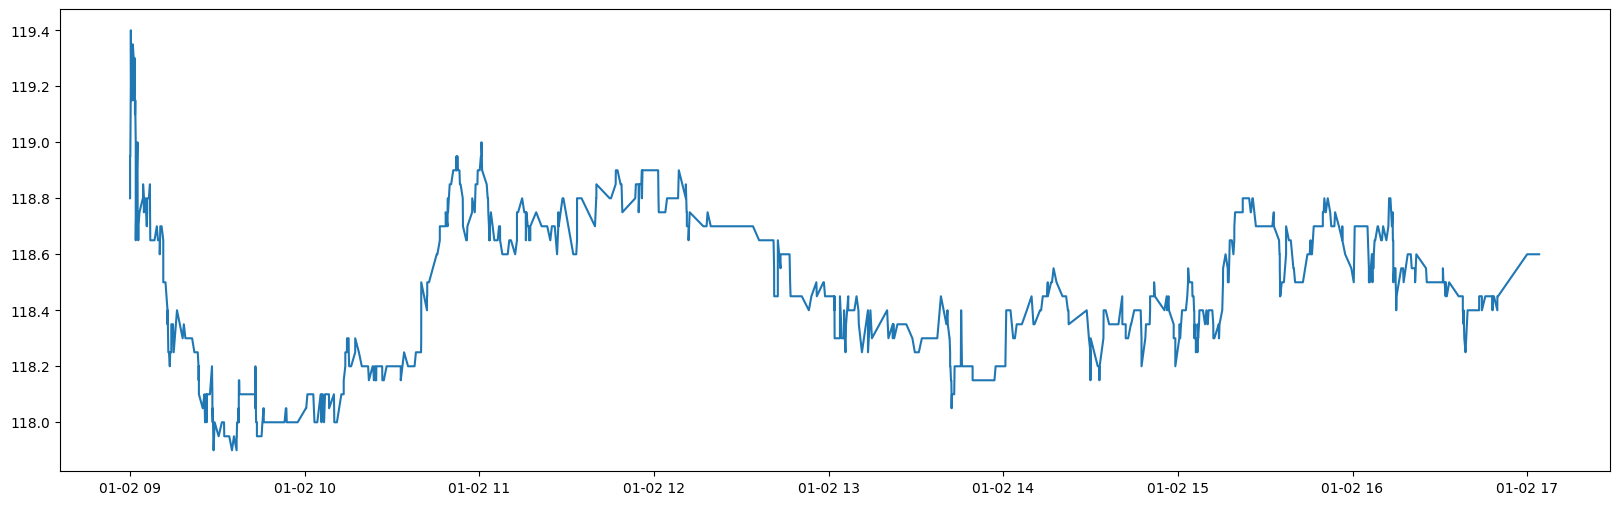

In [ ]:
fig = plt.figure(num=1, clear=True, figsize=(20, 6))
ax = fig.add_subplot(111)
ax.plot(sample_day["datetime"], sample_day["price"])
plt.show()

94


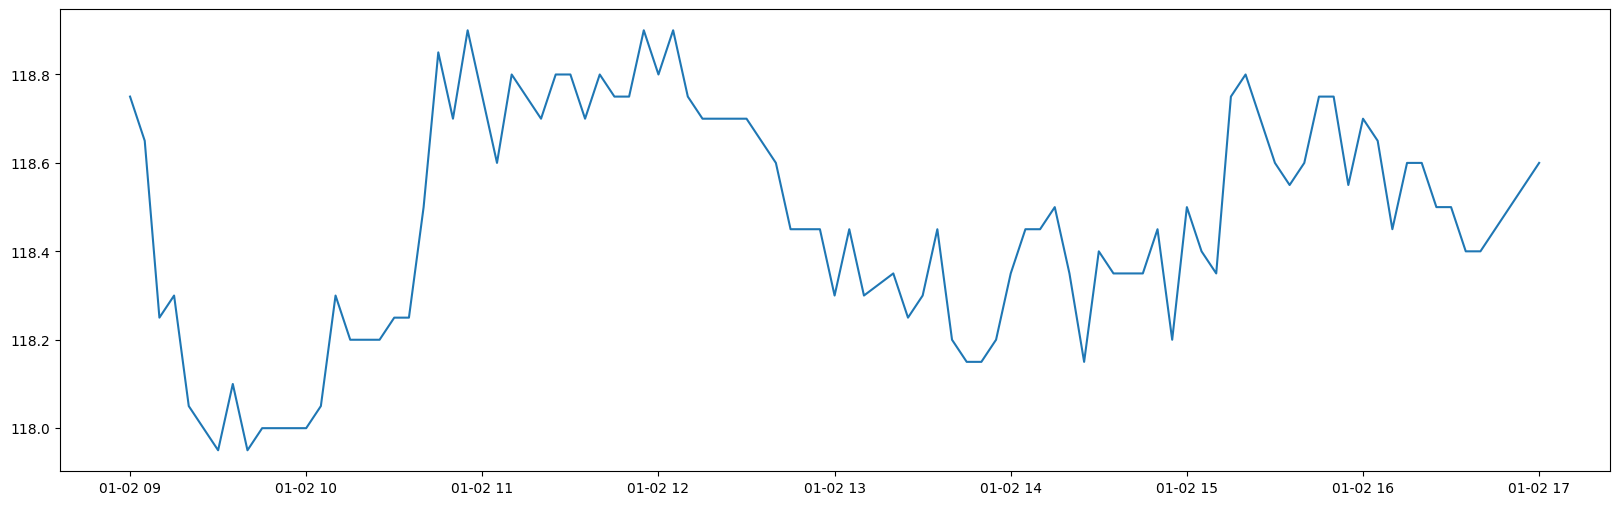

In [ ]:
sample_day2 = sample_day.set_index("datetime").resample("5min").agg("last").dropna()
print(len(sample_day2))

fig = plt.figure(num=1, clear=True, figsize=(20, 6))
ax = fig.add_subplot(111)
ax.plot(sample_day2.index, sample_day2["price"])
plt.show()

## Ćwiczenie
- Określenie problemu
- Przygotowanie danych
- Stworzenie modelu (bez attention)
- Trenowanie i ocena
- Dodanie warst attention
- Trenowanie i ocena
- Wizualizacja warstwy attention

In [ ]:
sample_x, sample_y = [], []

df_grouped = df.groupby(df["datetime"].dt.date)
for d, dfg in df_grouped:
    # resample only this day's data
    df_day = (
        dfg.set_index("datetime")
        .resample("5min")
        .agg({"price": "last", "volume": "sum", "trade_id": "count"})
    )

    # fill missing values
    df_day["price"] = df_day["price"].ffill()
    df_day["volume"] = df_day["volume"].fillna(0)
    df_day["trade_id"] = df_day["trade_id"].fillna(0)

    # keep only complete days with at least 95 intervals
    if len(df_day) >= 95:
        sample_x.append(df_day.values[:95])
        sample_y.append(df_day.values[-1, 0])

In [ ]:
lag = 5
nsamples_x = np.zeros((len(sample_x) - lag, 95, 3))
nsamples_y = np.zeros((len(sample_y) - lag,))
for i in range(lag, len(sample_x)):
    dx = sample_x[i - lag : i]
    dy = sample_y[i - lag : i]
    mx = np.mean(dx, axis=(0, 1))
    sx = np.std(dx, axis=(0, 1))
    nsamples_x[i - lag] = (sample_x[i] - mx) / (sx + 1e-8)
    my = np.mean(dy)
    sy = np.std(dy)
    nsamples_y[i - lag] = (sample_y[i] - my) / (sy + 1e-8)

In [32]:
len(sample_x), len(sample_y)

(1999, 1999)

In [57]:
# sample_x = np.array(sample_x)
# sample_y = np.array(sample_y)
sample_x = nsamples_x
sample_y = nsamples_y
print(sample_x.shape, sample_y.shape)

(1994, 95, 3) (1994,)


In [ ]:
train_size = int(0.77 * len(sample_x))
val_size = int(0.08 * len(sample_x))
test_size = len(sample_x) - train_size - val_size
x_train, y_train = sample_x[:train_size], sample_y[:train_size]
x_val, y_val = (
    sample_x[train_size : train_size + val_size],
    sample_y[train_size : train_size + val_size],
)
x_test, y_test = sample_x[train_size + val_size :], sample_y[train_size + val_size :]
print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (1535, 95, 3) (1535,)
Validation: (159, 95, 3) (159,)
Test: (300, 95, 3) (300,)


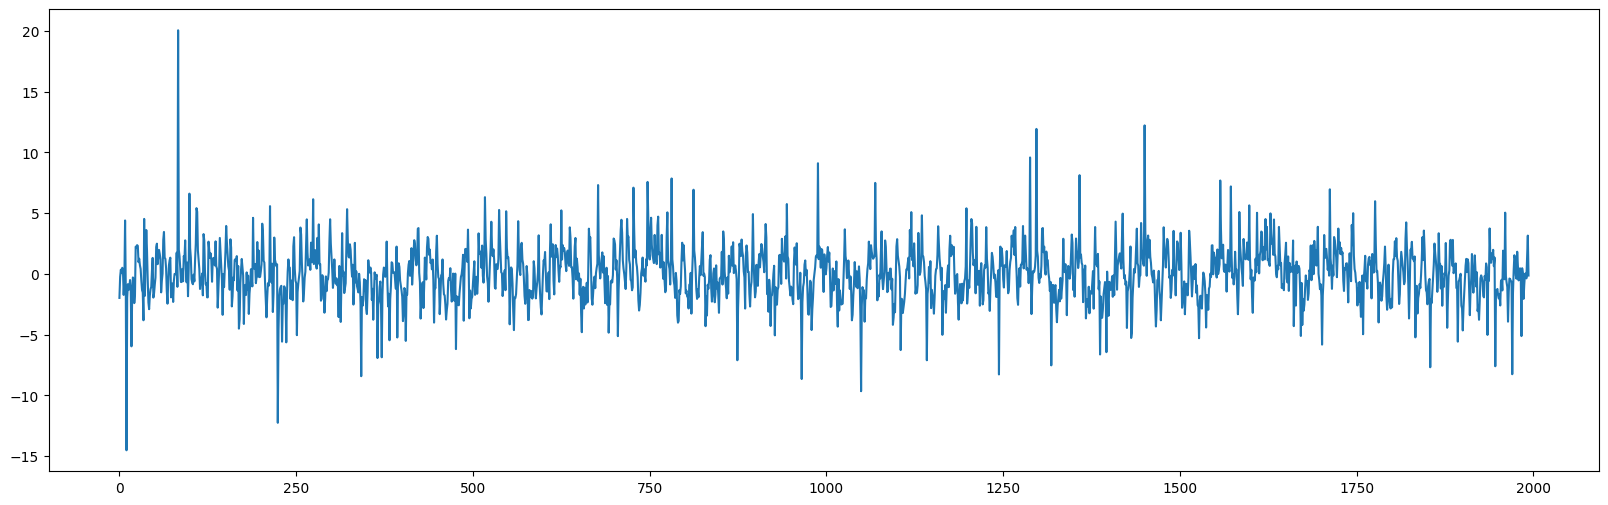

In [ ]:
fig = plt.figure(num=1, clear=True, figsize=(20, 6))
ax = fig.add_subplot(111)
ax.plot(range(len(sample_y)), sample_y)

In [60]:
from tensorflow import keras
from keras.layers import Input, LSTM, Dense, Flatten, Conv1D, MaxPooling1D, Dropout
from keras.models import Model, load_model
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [67]:
# Attention Mechanism
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [ ]:
x = Input(shape=(95, 3))
x1 = Conv1D(64, kernel_size=12, activation="relu", strides=15)(x)
y, h, _ = LSTM(128, return_sequences=True, return_state=True)(x1)
c, w = BahdanauAttention(128)(h, y)
y = Dense(1, activation="linear")(c)

model = Model(inputs=x, outputs=y)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 95, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 6, 64)     │      2,368 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ [(None, 6, 128),  │     98,816 │ conv1d_9[0][0]    │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ [(None, 128),     │     33,153 │ lstm_9[0][1],     │
│ (BahdanauAttention) │ (None, 6, 1)]     │            │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │        129 │ bahdanau_attenti… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,466 (525.26 KB)

 Trainable params: 134,466 (525.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# cb = ModelCheckpoint('lstm3.weights.keras', save_best_only=True, monitor='val_loss', mode='min', save_weights_only=True)
cb = ModelCheckpoint(
    "lstm3.weights.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    save_weights_only=True,
)
model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[cb],
)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.7296 - mae: 0.8518 - val_loss: 0.7480 - val_mae: 0.6086
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1964 - mae: 0.6930 - val_loss: 0.6325 - val_mae: 0.5604
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0686 - mae: 0.6495 - val_loss: 0.9523 - val_mae: 0.6925
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0304 - mae: 0.6352 - val_loss: 0.6328 - val_mae: 0.5378
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9728 - mae: 0.6153 - val_loss: 0.6575 - val_mae: 0.5520
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9348 - mae: 0.6128 - val_loss: 0.5049 - val_mae: 0.5035
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9100 - mae: 0.6126 - val_loss: 0.5686 - val_mae: 0.5376
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8483 - mae: 0.5946 - val_loss: 0.8364 - val_mae: 0.5949
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8474

In [ ]:
# best_model = load_model('lstm1.keras')
model.load_weights("lstm3.weights.h5")
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8673 - mae: 0.6149 
Test Loss: 0.8673, Test MAE: 0.6149


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


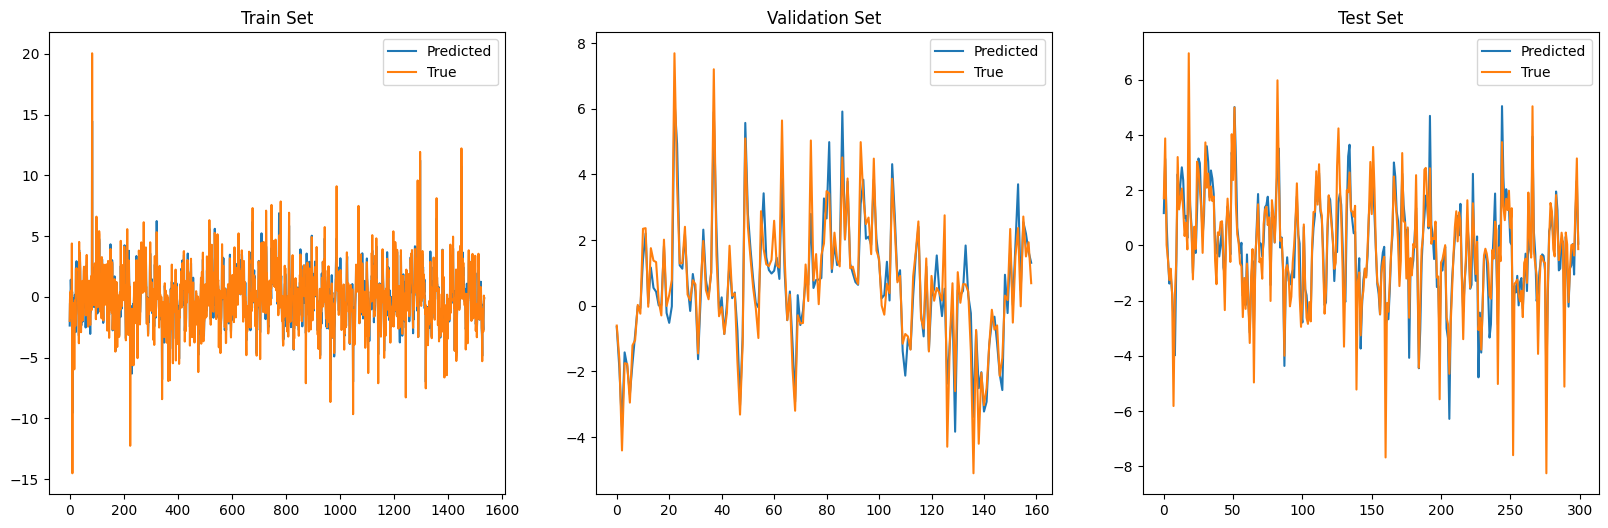

In [ ]:
# pred1 = best_model.predict(x_train)
# pred2 = best_model.predict(x_val)
# pred3 = best_model.predict(x_test)
pred1 = model.predict(x_train)
pred2 = model.predict(x_val)
pred3 = model.predict(x_test)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(pred1.flatten(), label="Predicted")
plt.plot(y_train, label="True")
plt.title("Train Set")
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(pred2.flatten(), label="Predicted")
plt.plot(y_val, label="True")
plt.title("Validation Set")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(pred3.flatten(), label="Predicted")
plt.plot(y_test, label="True")
plt.title("Test Set")
plt.legend()
plt.show()

In [ ]:
attention_model = Model(
    inputs=model.input, outputs=model.layers[-1].output
)  # Output from attention layer
attention_weights = attention_model.predict(x_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [104]:
x = x_test[100:105]  # Example input
c, w = attention_model.predict(x)
plt.figure(figsize=(10, 6))
plt.imshow(w.T, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("Attention Weights")
plt.xlabel("Time Steps")
plt.ylabel("Features")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


ValueError: too many values to unpack (expected 2)

array([[[2.2533586e-11],
        [1.0019872e-08],
        [7.9988524e-07],
        [1.3937741e-05],
        [2.4732277e-03],
        [9.9751198e-01]]], dtype=float32)